# Credit Scoring Model — Predicting Creditworthiness

**Objective:** Predict whether a loan applicant is a good or bad credit risk using their financial history.

**Dataset:** [Statlog (German Credit Data)](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data) — UCI Machine Learning Repository.
1000 loan applicants, 20 features (financial + demographic), target = credit risk (Good/Bad).

**Approach:**
1. Load & decode the dataset
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Train Logistic Regression, Decision Tree, Random Forest
5. Evaluate with Precision, Recall, F1-Score, ROC-AUC
6. Compare models and pick the best one


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

In [16]:
columns = [
    "checking_account_status", "duration_months", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment_since", "installment_rate_pct",
    "personal_status_sex", "other_debtors", "residence_since", "property",
    "age", "other_installment_plans", "housing", "existing_credits",
    "job", "num_dependents", "telephone", "foreign_worker", "credit_risk"
]

df = pd.read_csv("german_credit.csv", header=None, names=columns)
print(df.shape)
df.head()

(1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [17]:
code_maps = {
    "checking_account_status": {
        "A11": "< 0 DM", "A12": "0-200 DM", "A13": ">= 200 DM", "A14": "no checking account"
    },
    "credit_history": {
        "A30": "no credits/all paid", "A31": "all credits at this bank paid",
        "A32": "existing credits paid duly", "A33": "delay in past",
        "A34": "critical account/other credits"
    },
    "purpose": {
        "A40": "car (new)", "A41": "car (used)", "A42": "furniture/equipment",
        "A43": "radio/TV", "A44": "domestic appliances", "A45": "repairs",
        "A46": "education", "A47": "vacation", "A48": "retraining",
        "A49": "business", "A410": "others"
    },
    "savings_account": {
        "A61": "< 100 DM", "A62": "100-500 DM", "A63": "500-1000 DM",
        "A64": ">= 1000 DM", "A65": "unknown/none"
    },
    "employment_since": {
        "A71": "unemployed", "A72": "< 1 year", "A73": "1-4 years",
        "A74": "4-7 years", "A75": ">= 7 years"
    },
    "personal_status_sex": {
        "A91": "male: divorced/separated", "A92": "female: divorced/separated/married",
        "A93": "male: single", "A94": "male: married/widowed", "A95": "female: single"
    },
    "other_debtors": {
        "A101": "none", "A102": "co-applicant", "A103": "guarantor"
    },
    "property": {
        "A121": "real estate", "A122": "savings/life insurance",
        "A123": "car/other", "A124": "unknown/none"
    },
    "other_installment_plans": {
        "A141": "bank", "A142": "stores", "A143": "none"
    },
    "housing": {
        "A151": "rent", "A152": "own", "A153": "for free"
    },
    "job": {
        "A171": "unemployed/unskilled-nonresident", "A172": "unskilled-resident",
        "A173": "skilled employee/official", "A174": "management/self-employed/highly qualified"
    },
    "telephone": {
        "A191": "none", "A192": "yes"
    },
    "foreign_worker": {
        "A201": "yes", "A202": "no"
    }
}

for col, mapping in code_maps.items():
    df[col] = df[col].map(mapping)

# Target: 1 = Good credit risk, 2 = Bad credit risk -> convert to 0/1 (1 = Bad/default)
df["credit_risk"] = df["credit_risk"].map({1: 0, 2: 1})

df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account/other credits,radio/TV,1169,unknown/none,>= 7 years,4,male: single,none,4,real estate,67,none,own,2,skilled employee/official,1,yes,yes,0
1,0-200 DM,48,existing credits paid duly,radio/TV,5951,< 100 DM,1-4 years,2,female: divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee/official,1,none,yes,1
2,no checking account,12,critical account/other credits,education,2096,< 100 DM,4-7 years,2,male: single,none,3,real estate,49,none,own,1,unskilled-resident,2,none,yes,0
3,< 0 DM,42,existing credits paid duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male: single,guarantor,4,savings/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,0
4,< 0 DM,24,delay in past,car (new),4870,< 100 DM,1-4 years,3,male: single,none,4,unknown/none,53,none,for free,2,skilled employee/official,2,none,yes,1


Target distribution (0 = Good, 1 = Bad):
credit_risk
0    700
1    300
Name: count, dtype: int64
credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


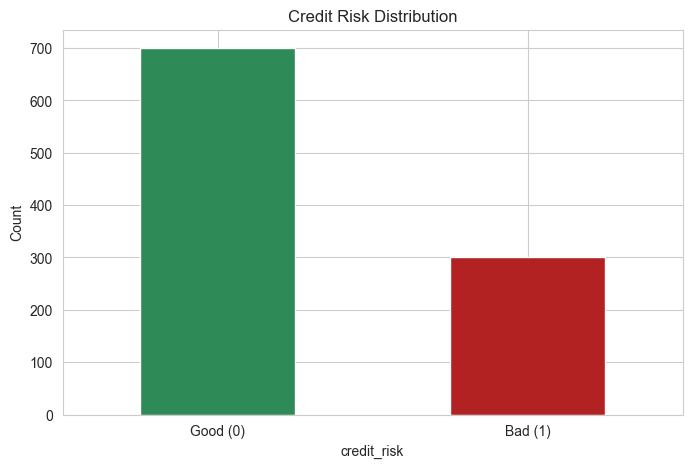

In [18]:
print("Target distribution (0 = Good, 1 = Bad):")
print(df["credit_risk"].value_counts())
print(df["credit_risk"].value_counts(normalize=True).round(3))

df["credit_risk"].value_counts().plot(kind="bar", color=["#2E8B57", "#B22222"])
plt.title("Credit Risk Distribution")
plt.xticks([0, 1], ["Good (0)", "Bad (1)"], rotation=0)
plt.ylabel("Count")
plt.show()

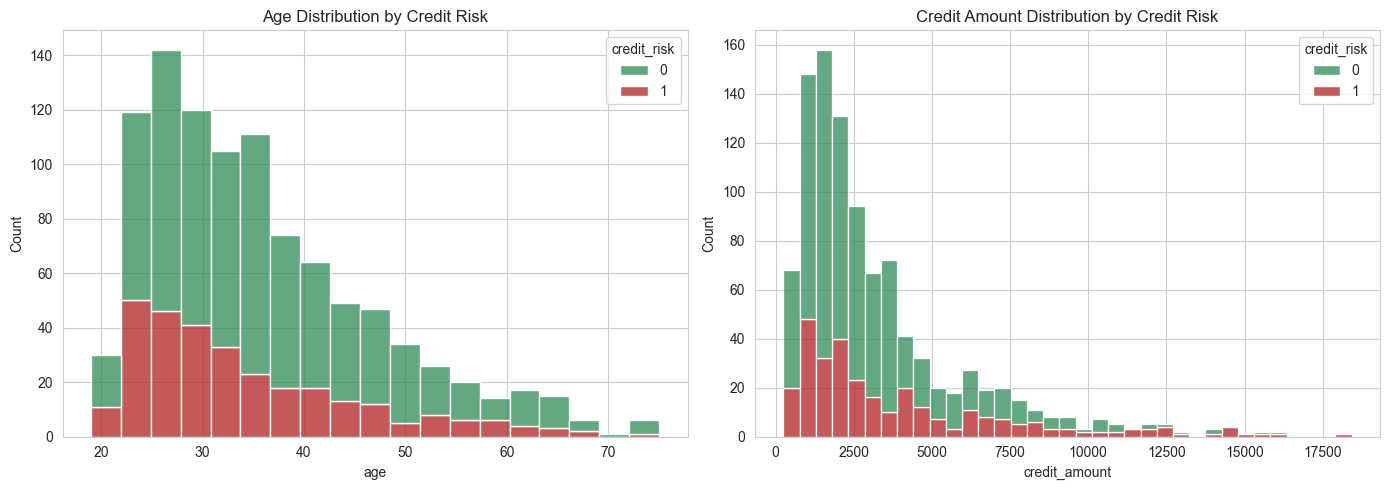

In [19]:
# Note the class imbalance: ~70% Good vs ~30% Bad.
# This is why accuracy alone is misleading -- Precision/Recall/F1/ROC-AUC matter more.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x="age", hue="credit_risk", multiple="stack", ax=axes[0], palette=["#2E8B57", "#B22222"])
axes[0].set_title("Age Distribution by Credit Risk")

sns.histplot(data=df, x="credit_amount", hue="credit_risk", multiple="stack", ax=axes[1], palette=["#2E8B57", "#B22222"])
axes[1].set_title("Credit Amount Distribution by Credit Risk")
plt.tight_layout()
plt.show()

C:\Users\My PC\AppData\Local\Temp\ipykernel_5616\38387007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="credit_risk", y="duration_months", palette=["#2E8B57", "#B22222"])


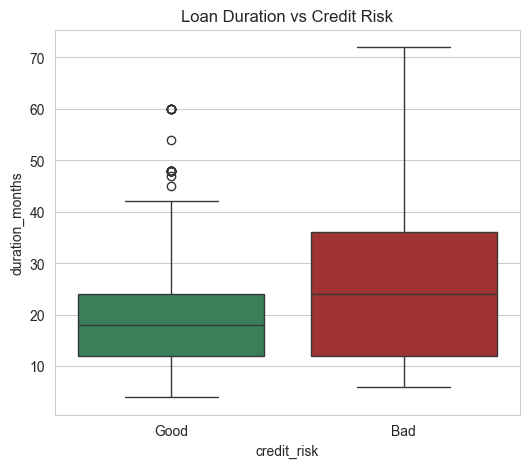

In [20]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="credit_risk", y="duration_months", palette=["#2E8B57", "#B22222"])
plt.xticks([0, 1], ["Good", "Bad"])
plt.title("Loan Duration vs Credit Risk")
plt.show()

In [21]:
df_fe = df.copy()

# 1. Repayment burden approximation
df_fe["credit_per_month"] = df_fe["credit_amount"] / df_fe["duration_months"]

# 2. Age buckets
df_fe["age_group"] = pd.cut(df_fe["age"], bins=[18, 25, 35, 50, 75],
                             labels=["18-25", "26-35", "36-50", "51+"])

# 3. Ordinal encode account status (more funds = lower risk ordinal)
checking_order = {"no checking account": 0, "< 0 DM": 1, "0-200 DM": 2, ">= 200 DM": 3}
savings_order = {"unknown/none": 0, "< 100 DM": 1, "100-500 DM": 2, "500-1000 DM": 3, ">= 1000 DM": 4}
df_fe["checking_account_status_ord"] = df_fe["checking_account_status"].map(checking_order)
df_fe["savings_account_ord"] = df_fe["savings_account"].map(savings_order)

df_fe[["credit_amount", "duration_months", "credit_per_month", "age_group",
       "checking_account_status_ord", "savings_account_ord"]].head()

,credit_amount,duration_months,credit_per_month,age_group,checking_account_status_ord,savings_account_ord
0,1169,6,194.833333,51+,1,0
1,5951,48,123.979167,18-25,2,1
2,2096,12,174.666667,36-50,0,1
3,7882,42,187.666667,36-50,1,1
4,4870,24,202.916667,51+,1,1


In [22]:
# One-hot encode remaining nominal categorical columns
nominal_cols = ["credit_history", "purpose", "employment_since", "personal_status_sex",
                "other_debtors", "property", "other_installment_plans", "housing",
                "job", "telephone", "foreign_worker", "age_group"]

df_model = pd.get_dummies(df_fe.drop(columns=["checking_account_status", "savings_account"]),
                           columns=nominal_cols, drop_first=True)

print(df_model.shape)
df_model.columns.tolist()[:15]

(1000, 48)


['duration_months',
 'credit_amount',
 'installment_rate_pct',
 'residence_since',
 'age',
 'existing_credits',
 'num_dependents',
 'credit_risk',
 'credit_per_month',
 'checking_account_status_ord',
 'savings_account_ord',
 'credit_history_critical account/other credits',
 'credit_history_delay in past',
 'credit_history_existing credits paid duly',
 'credit_history_no credits/all paid']

## 5. Train/Test Split & Scaling

In [23]:
X = df_model.drop(columns=["credit_risk"])
y = df_model["credit_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train target balance:\n{y_train.value_counts(normalize=True).round(3)}")

Train shape: (750, 47), Test shape: (250, 47)
Train target balance:
credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
}

results = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba
    }

results_df = pd.DataFrame({k: {m: v for m, v in val.items() if m != "y_pred" and m != "y_proba"}
                            for k, val in results.items()}).T
results_df.round(3)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.712,0.514,0.760,0.613,0.780
Decision Tree,0.632,0.434,0.747,0.549,0.690
Random Forest,0.792,0.662,0.627,0.644,0.814


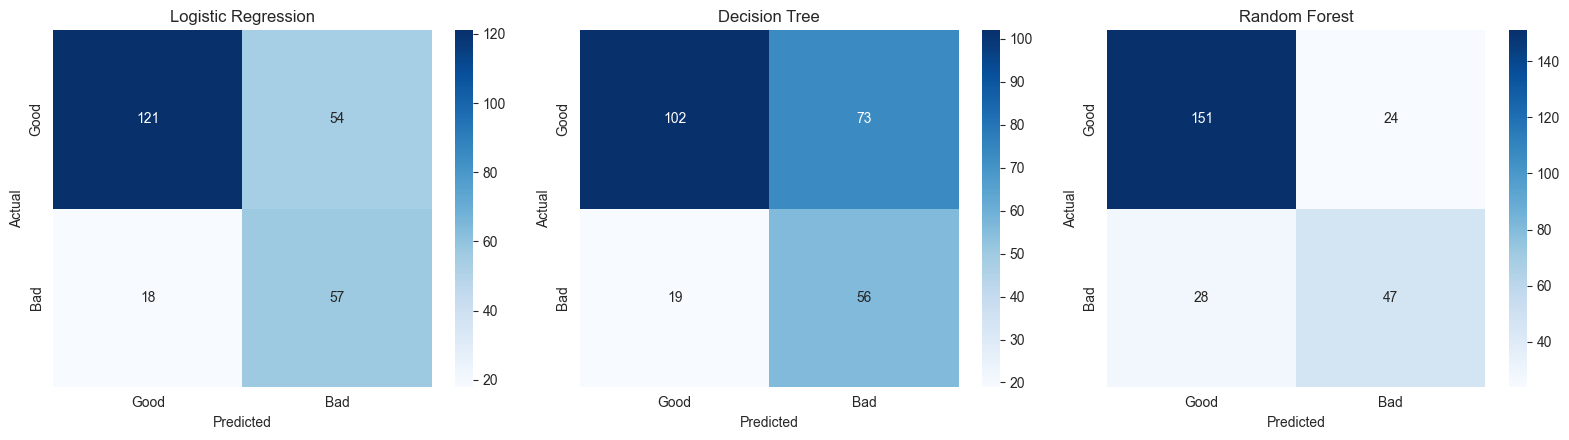

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

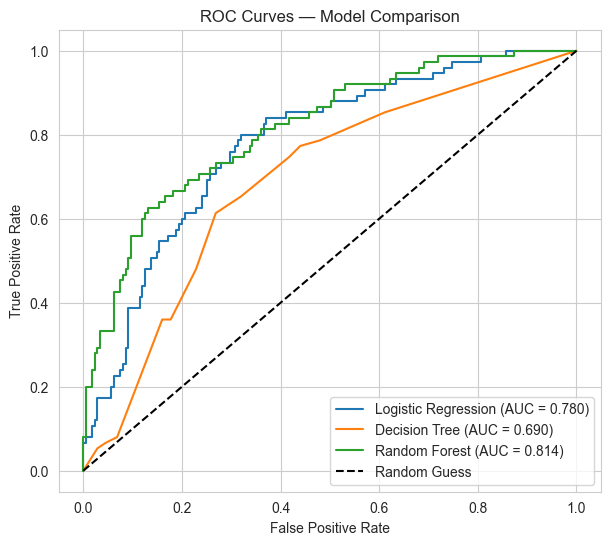

In [26]:
plt.figure(figsize=(7, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()

In [27]:
best_model_name = results_df["ROC-AUC"].idxmax()
print(f"Best model by ROC-AUC: {best_model_name}\n")
print(classification_report(y_test, results[best_model_name]["y_pred"],
                             target_names=["Good", "Bad"]))

Best model by ROC-AUC: Random Forest

              precision    recall  f1-score   support

        Good       0.84      0.86      0.85       175
         Bad       0.66      0.63      0.64        75

    accuracy                           0.79       250
   macro avg       0.75      0.74      0.75       250
weighted avg       0.79      0.79      0.79       250



## 8. Feature Importance (Random Forest)

Which factors drive the model's decisions the most.

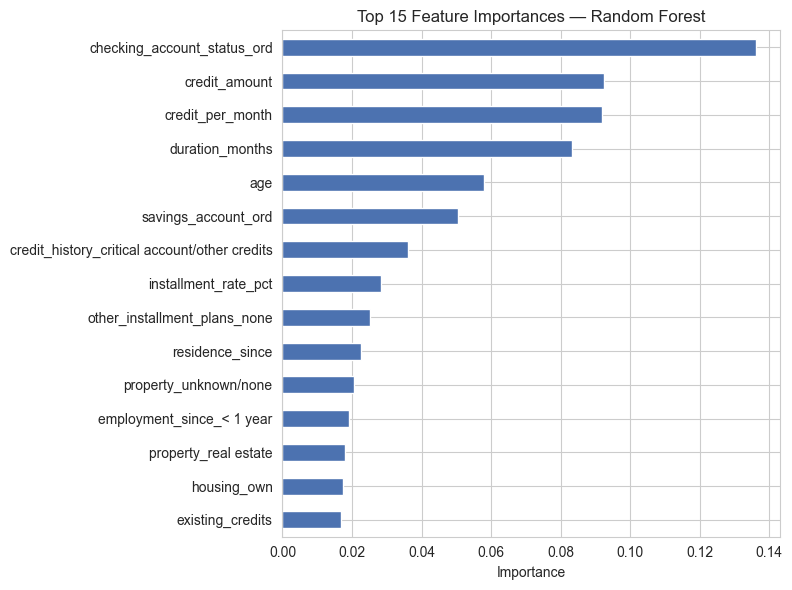

In [28]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()